# Malaga — Listings: Exploration & Cleaning
**Input :** `../../Data/raw/Malaga/listings.csv.gz`  
**Output:** `../../Data/interim/malaga_listings_clean.parquet`

Runs the shared `clean_listings()` pipeline, applies city-specific outlier
decisions, and exports a clean Parquet file consumed by the analysis notebook.

In [1]:
# !pip install pyarrow wordcloud textblob  # run once if needed

In [2]:
import sys
sys.path.insert(0, "../..")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import f_oneway, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from airbnb_iip.data.cleaning import (
    clean_listings, missing_report,
    standardize_property_type, rate_bucket,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 200)

## 1 · Load raw data

In [3]:
l_df_raw = pd.read_csv(
    "../../Data/raw/Malaga/listings.csv.gz",
    compression="gzip",
    low_memory=False,
)
print(f"Shape  : {l_df_raw.shape}")
print(f"Memory : {l_df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape  : (25000, 79)
Memory : 106.9 MB


## 2 · Initial exploration

In [4]:
l_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            25000 non-null  int64  
 1   listing_url                                   25000 non-null  object 
 2   scrape_id                                     25000 non-null  int64  
 3   last_scraped                                  25000 non-null  object 
 4   source                                        25000 non-null  object 
 5   name                                          25000 non-null  object 
 6   description                                   24130 non-null  object 
 7   neighborhood_overview                         10586 non-null  object 
 8   picture_url                                   24999 non-null  object 
 9   host_id                                       25000 non-null 

In [5]:
display(l_df_raw.head())
display(l_df_raw.tail())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,21853,https://www.airbnb.com/rooms/21853,20250914152907,2025-09-15,previous scrape,Bright and airy room,"We have a quiet and sunny room with a good view in our 3 bedroom flat. In a welcoming atmosphere, our clean and respectful flatshare is located in a leafy neighbourhood with all facilities: shops,...","We live in a leafy neighbourhood with plenty of green areas and recreational opportunities such as the library, gyms, swimming pools (covered and summer ones), and the tennis courts. Parking is fr...",https://a0.muscache.com/pictures/68483181/87bcac58_original.jpg,83531,https://www.airbnb.com/users/show/83531,Abdel,2010-02-21,"Malaga, Spain","EN-ES-FR\r\nEN\r\nHi everybody: I'm Abdel. I'm spanish originaly from Casablanca (Morocco). I've been living for many years in Andlusian area and now in Malaga that I like very much, since 11 year...",within a day,100%,NaN,f,https://a0.muscache.com/im/users/83531/profile_pic/1338760896/original.jpg?aki_policy=profile_small,https://a0.muscache.com/im/users/83531/profile_pic/1338760896/original.jpg?aki_policy=profile_x_medium,Aluche,2.0,2.0,"['email', 'phone']",t,t,"Malaga, Spain",Cármenes,Latina,40.40381,-3.74130,Private room in rental unit,Private room,1,NaN,1 bath,NaN,NaN,"[""First aid kit"", ""Hair dryer"", ""Bed linens"", ""Cooking basics"", ""Shampoo"", ""Wifi"", ""Dishes and silverware"", ""Microwave"", ""Hot water"", ""Hangers"", ""Extra pillows and blankets"", ""Coffee maker"", ""Air ...",NaN,4,40,4.0,4.0,40.0,40.0,4.0,40.0,NaN,t,0,0,0,198,2025-09-15,33,0,0,0,0,0,NaN,2014-10-10,2018-07-15,4.58,4.72,4.56,4.75,4.82,4.21,4.67,NaN,f,2,0,2,0,0.25
1,30320,https://www.airbnb.com/rooms/30320,20250914152907,2025-09-15,city scrape,Apartamentos Dana Sol,NaN,NaN,https://a0.muscache.com/pictures/336868/f67409fb_original.jpg,130907,https://www.airbnb.com/users/show/130907,Danuta Weronika,2010-05-24,"Malaga, Spain","Apartasol offers a network of several spacious, comfortable apartments in the vibrant heart of Malaga. The apartments are situated in three different locations, all very central and within walkin...",within an hour,100%,100%,f,https://a0.muscache.com/im/users/130907/profile_pic/1373028590/original.jpg?aki_policy=profile_small,https://a0.muscache.com/im/users/130907/profile_pic/1373028590/original.jpg?aki_policy=profile_x_medium,Sol,17.0,18.0,"['email', 'phone']",t,t,NaN,Sol,Centro,40.41476,-3.70418,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""TV with standard cable"", ""Elevator"", ""Air conditioning"", ""Kitchen"", ""Heating"", ""Wifi""]",$157.00,5,50,1.0,7.0,50.0,50.0,5.0,50.0,Na

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
24995,1508016618526988093,https://www.airbnb.com/rooms/1508016618526988093,20250914152907,2025-09-14,city scrape,Amplio apartamento con Terraza,"Spacious one-bedroom apartment with a terrace, located one street from the Pacific Metro, it has several bus stops nearby, supermarkets, restaurants.",NaN,https://a0.muscache.com/pictures/hosting/Hosting-1508016618526988093/original/04d6cb78-8d75-4ba5-a8ab-c67f16f266bf.jpeg,446760611,https://www.airbnb.com/users/show/446760611,Raul,2022-02-25,NaN,Asesor inmobiliario,a few days or more,46%,20%,f,https://a0.muscache.com/im/pictures/user/5d8de3c3-b681-4534-834b-9efa2d11ab54.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/5d8de3c3-b681-4534-834b-9efa2d11ab54.jpg?aki_policy=profile_x_medium,NaN,41.0,43.0,['phone'],t,t,NaN,Pacífico,Retiro,40.401080,-3.676530,Entire rental unit,Entire home/apt,4,1.0,1 bath,1.0,1.0,"[""Hair dryer"", ""Bed linens"", ""Dishes and silverware"", ""Wifi"", ""Microwave"", ""Hot water"", ""Hangers"", ""Extra pillows and blankets"", ""Stove"", ""Air conditioning"", ""Coffee maker"", ""Kitchen"", ""Drying rac...",$89.00,1,365,1.0,1.0,365.0,365.0,1.0,365.0,NaN,t,11,36,62,324,2025-09-14,0,0,0,75,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ESABCD123456789123456789123456789123456-HH-7891234567,f,36,36,0,0,NaN
24996,1508029370917448986,https://www.airbnb.com/rooms/1508029370917448986,20250914152907,2025-09-15,city scrape,Piso de hasta 4 huéspedes en el centro de Malaga,"Charming Downtown Apartment Perfect for your Malaga Stay!<br />Enjoy a comfortable and cozy stay in the heart of the city. This charming 1 bedroom apartment is ideal for couples, families or group...",NaN,https://a0.muscache.com/pictures/hosting/Hosting-1508029370917448986/original/d8f864e5-dcae-4f39-b5d9-5d08df8d19d1.jpeg,401215824,https://www.airbnb.com/users/show/401215824,Ines,2021-05-12,"Malaga, Spain",NaN,within an hour,100%,100%,f,https://a0.muscache.com/im/pictures/user/f707397d-e20d-49e2-a4a5-3b14cacc84f5.jpg?aki_policy=profile_small,https://a0.muscache.com/im/pictures/user/f707397d-e20d-49e2-a4a5-3b14cacc84f5.jpg?aki_policy=profile_x_medium,NaN,1.0,3.0,"['email', 'phone']",t,t,NaN,Palacio,Centro,40.411513,-3.713762,Entire rental unit,Entire home/apt,4,1.0,1 bath,1.0,1.0,"[""Cleaning products"", ""Hair dryer"", ""Private entrance"", ""Bed linens"", ""Portable fans"", ""Cooking basics"", ""Board games"", ""Wifi"", ""Dishes and silverware"", ""Microwave"", ""Mini fridge"", ""Laundromat nea...",$140.00,4,365,4.0,4.0,365.0,365.0,4.0,365.0,NaN,t,10,40,57,283,2025-09-15,0,0,0,57,0,0,0.0,NaN,NaN,Na

In [6]:
l_df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,25000.0,7.248274e+17,5.719092e+17,2.185300e+04,3.974878e+07,9.026240e+17,1.237047e+18,1.508659e+18
scrape_id,25000.0,2.025091e+13,0.000000e+00,2.025091e+13,2.025091e+13,2.025091e+13,2.025091e+13,2.025091e+13
host_id,25000.0,2.806729e+08,2.200065e+08,1.745300e+04,6.184860e+07,2.542674e+08,4.690354e+08,7.184549e+08
host_listings_count,24903.0,6.317448e+01,1.534476e+02,1.000000e+00,1.000000e+00,5.000000e+00,3.400000e+01,1.487000e+03
host_total_listings_count,24903.0,7.516845e+01,1.751954e+02,1.000000e+00,2.000000e+00,7.000000e+00,4.400000e+01,2.767000e+03
latitude,25000.0,4.042233e+01,2.366520e-02,4.033140e+01,4.040967e+01,4.042083e+01,4.043282e+01,4.053553e+01
longitude,25000.0,-3.693734e+00,2.823187e-02,-3.832060e+00,-3.707486e+00,-3.700850e+00,-3.684085e+00,-3.545904e+00
accommodates,25000.0,3.169920e+00,1.921082e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.600000e+01
bathrooms,18960.0,1.310021e+00,7.047792e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.500000e+00,1.900000e+01
bedrooms,22488.0,1.429340e+00,9.691217e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.500000e+01


,missing_count,missing_percent
calendar_updated,25000,100.000
host_neighbourhood,17078,68.312
license,15812,63.248
neighborhood_overview,14414,57.656
neighbourhood,14414,57.656
host_about,12402,49.608
host_location,8150,32.600
price,6047,24.188
estimated_revenue_l365d,6047,24.188
bathrooms,6040,24.160


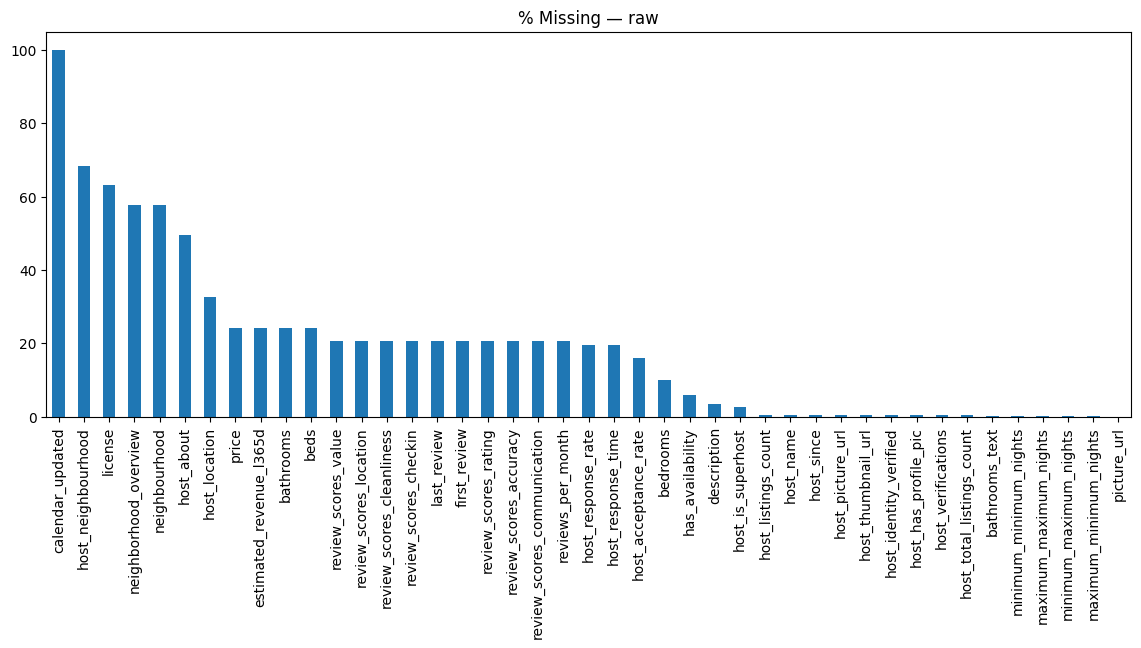

In [7]:
mr_raw = missing_report(l_df_raw)
mr_raw[mr_raw.missing_count > 0]["missing_percent"].plot(
    kind="bar", figsize=(14, 5), title="% Missing — raw"
)
display(mr_raw.head(20))

In [8]:
# Unique-value counts — categorical columns (skip long free-text)
_skip = {"description", "host_about", "neighborhood_overview", "amenities", "name"}
for col in l_df_raw.select_dtypes("object").columns.difference(_skip):
    print(f"\n{col}  ({l_df_raw[col].nunique()} unique)")
    print(l_df_raw[col].value_counts().head(6).to_string())


bathrooms_text  (38 unique)
bathrooms_text
1 bath            12677
2 baths            3588
1 shared bath      3258
1 private bath     1908
1.5 baths           738
2 shared baths      627

calendar_last_scraped  (2 unique)
calendar_last_scraped
2025-09-15    16268
2025-09-14     8732

first_review  (3571 unique)
first_review
2019-06-02    54
2025-08-31    52
2025-07-06    47
2025-04-06    43
2025-04-27    43
2024-07-14    42

has_availability  (1 unique)
has_availability
t    23536

host_acceptance_rate  (101 unique)
host_acceptance_rate
100%    7843
99%     2590
98%     1363
97%      856
0%       765
94%      562

host_has_profile_pic  (2 unique)
host_has_profile_pic
t    23888
f     1015

host_identity_verified  (2 unique)
host_identity_verified
t    22407
f     2496

host_is_superhost  (2 unique)
host_is_superhost
f    18933
t     5399

host_location  (440 unique)
host_location
Malaga, Spain             14582
Barcelona, Spain            678
Spain                       153
London, Un

In [9]:
# Numeric ranges — flag obvious anomalies before cleaning
for col in l_df_raw.select_dtypes(include=["int64", "float64"]).columns:
    print(f"{col}: min={l_df_raw[col].min()}, max={l_df_raw[col].max()}")

id: min=21853, max=1508659056613604207
scrape_id: min=20250914152907, max=20250914152907
host_id: min=17453, max=718454859
host_listings_count: min=1.0, max=1487.0
host_total_listings_count: min=1.0, max=2767.0
latitude: min=40.3314, max=40.53553
longitude: min=-3.83206, max=-3.5459040932605648
accommodates: min=1, max=16
bathrooms: min=0.0, max=19.0
bedrooms: min=0.0, max=25.0
beds: min=0.0, max=40.0
minimum_nights: min=1, max=1125
maximum_nights: min=1, max=11111
minimum_minimum_nights: min=1.0, max=1125.0
maximum_minimum_nights: min=1.0, max=1125.0
minimum_maximum_nights: min=1.0, max=11111.0
maximum_maximum_nights: min=1.0, max=11111.0
minimum_nights_avg_ntm: min=1.0, max=1125.0
maximum_nights_avg_ntm: min=1.0, max=11111.0
calendar_updated: min=nan, max=nan
availability_30: min=0, max=30
availability_60: min=0, max=60
availability_90: min=0, max=90
availability_365: min=0, max=365
number_of_reviews: min=0, max=1184
number_of_reviews_ltm: min=0, max=590
number_of_reviews_l30d: min=0

In [10]:
# Duplicate check
print("Full duplicates           :", l_df_raw.duplicated().sum())
print("Duplicate listing ids     :", l_df_raw.duplicated(subset=['id']).sum())

# duplicated everything except the id 
# Count rows where everything matches except id
cols_except_id = l_df_raw.columns.difference(['id']).tolist()
dup_except_id_count = l_df_raw.duplicated(subset=cols_except_id).sum()
print("Duplicated except ids:", dup_except_id_count)    

# same name + host + coords - indicates host owns whole building. 
print("Duplicate (name+host+coords):",
      l_df_raw.duplicated(subset=['name','host_id','latitude','longitude']).sum())


Full duplicates           : 0
Duplicate listing ids     : 0
Duplicated except ids: 0
Duplicate (name+host+coords): 196


## 3 · Cleaning pipeline

`clean_listings()` handles (in order):
1. Drop `calendar_updated`, `neighbourhood` (always useless)
2. Deduplicate ignoring `id` / `listing_url`
3. Parse dates, prices, rates, booleans
4. Normalise multi-host name separators → `&`
5. Reconcile `bathrooms` / `bathrooms_text` (fixes the `fillna("mode")` bug from legacy code)
6. Hierarchical imputation — host fields → price → beds/bedrooms
7. Review-score zeros / sentinel dates for never-reviewed listings
8. Temporal features: `host_tenure_years`, `days_since_*`, `review_span_years`
9. Engineered features: `property_type_std`, rate categories, `price_cat` (city-adaptive quartiles), `description_length`
10. Drop URL / thumbnail columns

In [11]:
l_df = clean_listings(l_df_raw)
print(f"After clean_listings(): {l_df.shape}")
l_df.info()

After clean_listings(): (18864, 79)
<class 'pandas.core.frame.DataFrame'>
Index: 18864 entries, 1 to 24999
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            18864 non-null  int64         
 1   scrape_id                                     18864 non-null  int64         
 2   last_scraped                                  18864 non-null  datetime64[ns]
 3   source                                        18864 non-null  object        
 4   name                                          18864 non-null  object        
 5   description                                   18304 non-null  object        
 6   neighborhood_overview                         18864 non-null  object        
 7   picture_url                                   18864 non-null  object        
 8   host_id                            

### City-specific decisions

Document outlier thresholds and the EDA evidence that justifies them.

In [12]:
# Malaga-specific: extreme bed / bedroom counts found during EDA above
l_df = l_df[~((l_df['beds'] == 40) | (l_df['bedrooms'] == 25))]
print(f'After city-specific outlier removal: {l_df.shape}')

After city-specific outlier removal: (18862, 79)


,missing_count,missing_percent
review_scores_cleanliness,3091,16.387446
review_scores_checkin,3091,16.387446
review_scores_communication,3090,16.382144
review_scores_location,3090,16.382144
review_scores_value,3090,16.382144
review_span_years,3090,16.382144
days_since_last_review,3090,16.382144
days_since_first_review,3090,16.382144
review_scores_rating,3090,16.382144
review_scores_accuracy,3090,16.382144


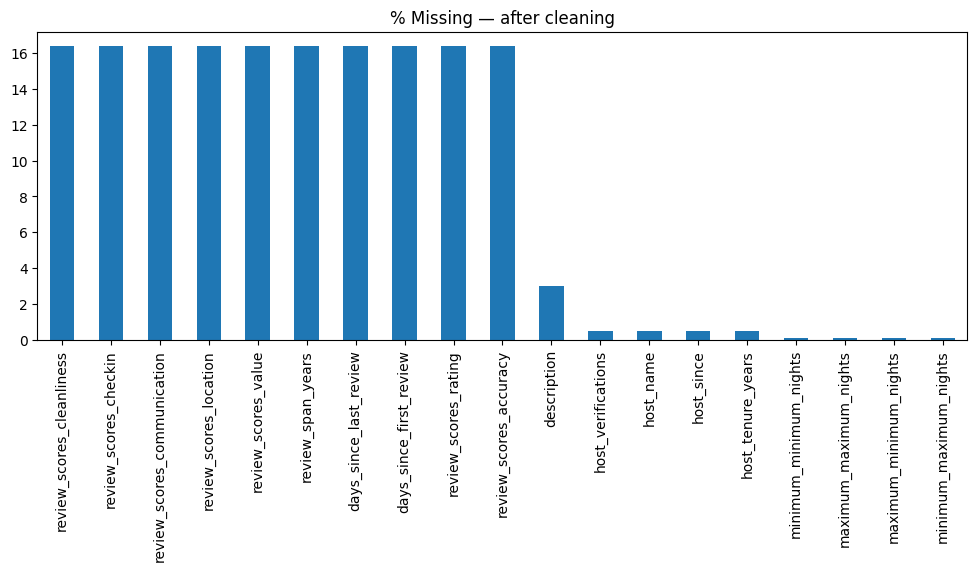

In [13]:
mr_clean = missing_report(l_df)
remaining = mr_clean[mr_clean.missing_count > 0]
if remaining.empty:
    print("No missing values remaining ✓")
else:
    display(remaining)
    remaining["missing_percent"].plot(
        kind="bar", figsize=(12, 4), title="% Missing — after cleaning"
    )

In [14]:
# Confirm final dtypes and feature set
l_df.info()
print("\nEngineered columns added:")
new_cols = set(l_df.columns) - set(l_df_raw.columns)
print(sorted(new_cols))

<class 'pandas.core.frame.DataFrame'>
Index: 18862 entries, 1 to 24999
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            18862 non-null  int64         
 1   scrape_id                                     18862 non-null  int64         
 2   last_scraped                                  18862 non-null  datetime64[ns]
 3   source                                        18862 non-null  object        
 4   name                                          18862 non-null  object        
 5   description                                   18302 non-null  object        
 6   neighborhood_overview                         18862 non-null  object        
 7   picture_url                                   18862 non-null  object        
 8   host_id                                       18862 non-null  int64    

## 4 · Export cleaned parquet

Output: `../../Data/interim/malaga_listings_clean.parquet`

In [15]:
import pathlib

out_path = pathlib.Path("../../Data/interim/malaga_listings_clean.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

l_df.to_parquet(out_path, index=False, engine="pyarrow")

print(f"Saved {l_df.shape[0]:,} rows × {l_df.shape[1]} cols → {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved 18,862 rows × 79 cols → ../../Data/interim/malaga_listings_clean.parquet
File size: 10.0 MB
